In this notebook, we will analyze the scope examples shown in figure 3C that display scopes for the high-average amide dataset (DS4) for ScopeBO, clustering and conventional selection.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..','..','..')))
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.cluster import hierarchy
from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from sklearn.preprocessing import scale
from scipy.spatial.distance import cdist
from Code.predictor import ScopeBO
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import colorsys


# Doyle colors
doyle_colors = ["#CE4C6F", "#1561C2", "#188F9D","#C4ADA2","#515798", "#CB7D85", "#A9A9A9"]
# extension of palette with lighter and darker versions
def adjust_lightness(color, factor=1.2):
    """
    Function to make colors lighter (factor > 1) or darker (factor < 1).
    """
    r, g, b = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = max(0, min(1, l * factor))
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return mcolors.to_hex((r, g, b))

lighter = [adjust_lightness(c, 1.2) for c in doyle_colors]
darker  = [adjust_lightness(c, 0.7) for c in doyle_colors]
all_colors = doyle_colors + darker[::-1] + lighter[::-1] 

# Save the categorical colormap
cat_cmap = ListedColormap(all_colors, name="Doyle_cat")
plt.colormaps.register(cat_cmap)

# Define and save a continuous colormap
colors = [doyle_colors[1],"#FFFFFFD1",doyle_colors[0]]
cont_cmap = LinearSegmentedColormap.from_list("Doyle_cont", colors)
plt.colormaps.register(cont_cmap)

# General plt parameters
plt.rcParams.update({
    "axes.titlesize": 20,        # Subplot title
    "axes.labelsize": 16,        # X and Y labels
    "figure.titlesize": 24,      # Suptitle
    "xtick.labelsize": 14,       # X tick labels
    "ytick.labelsize": 14,       # Y tick labels
    "legend.fontsize": 14,       # Legend text
    "legend.title_fontsize": 14, # Legend titles
    "font.family": "Helvetica"   # Font
    })

In [2]:
# define a couple things
objectives = ["yield"]
directory = "."
wdir = Path(directory)
dset = "high"  # only looking at DS4 here

In [3]:
# load the normalization bounds
df_bounds = pd.read_csv(f"./../Amide_data/Datasets/bounds_subs.csv", index_col=0)

# define a function to extract the relevant bounds in a format suitable for the Benchmark class
def get_bounds(dset):
    bounds = {}
    # get the metrics for the yield objective
    bounds["yield"] = (df_bounds.loc["obj_max",dset],df_bounds.loc["obj_min",dset])
    # get the metrics for the vendi score
    bounds["vendi"] = (df_bounds.loc["vendi_max",dset],df_bounds.loc["vendi_min",dset])

    return bounds

df_bounds

,high,medium,low
obj_min,0.524635,0.344322,0.152959
obj_max,0.705849,0.441517,0.347364
vendi_min,2.889390,2.903768,2.895324
vendi_max,9.740334,9.731709,9.770858


Visualize the scopes on a PCA

scopebo selected samples on PCA.


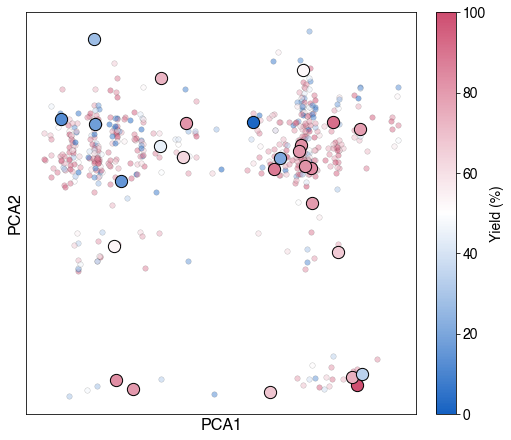

convsel selected samples on PCA.


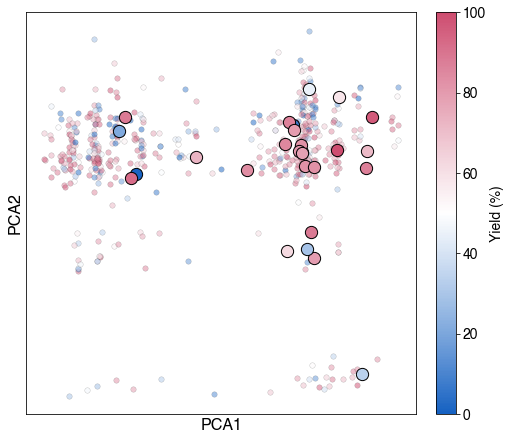

clust selected samples on PCA.


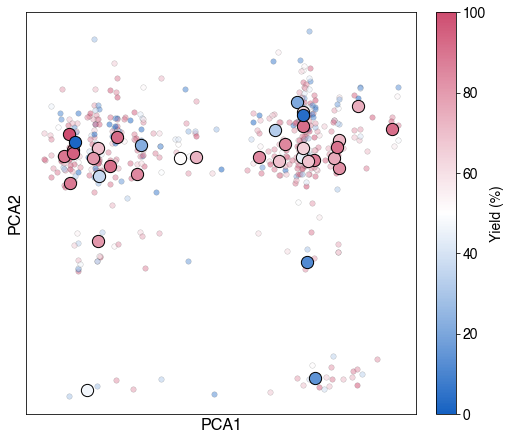

In [27]:
# make a PCA of the dataset and visualize the scope samples

# drop the features and scale the data
df_scaled = df_labelled.copy(deep=True)
df_scaled = df_scaled.drop(columns=['yield','clusters'])  # drop then non-feature columns
df_scaled = pd.DataFrame(scale(df_scaled),df_scaled.index,df_scaled.columns)  # scale the data

# do the PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=0)
pca_result = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(pca_result, index=df_scaled.index, columns=["PCA1","PCA2"])

# add the yields and clusters back to the PCA dataframe
df_pca["yield"] = df_labelled["yield"]
df_pca["yield"] = df_pca["yield"]*100  # convert to percentage for better visualization
df_pca["clusters"] = df_labelled["clusters"]

# normalization for 0–100 yields
norm = Normalize(vmin=0, vmax=100)

for method in methods:

    fig, ax = plt.subplots(figsize=(7,6), constrained_layout=True)

    ax.set_xlabel("PCA1", fontsize=16)
    ax.set_ylabel("PCA2", fontsize=16)

    selected = scopes[method][scopes[method]["yield"] != "PENDING"].index

    for sample in df_pca.index:

        # yield already converted to 0–100
        yield_val = df_pca.loc[sample, "yield"]

        # map yield to color
        color = cont_cmap(norm(yield_val))

        if sample in selected:
            ax.scatter(
                df_pca.loc[sample, "PCA1"],
                df_pca.loc[sample, "PCA2"],
                color=color,
                s=150,
                alpha=1,
                edgecolor='k',
                linewidth=1,
                zorder=2
            )

        else:
            # non-selected samples
            ax.scatter(
                df_pca.loc[sample, "PCA1"],
                df_pca.loc[sample, "PCA2"],
                color=color,
                s=30,
                alpha=0.5,
                edgecolor='k',
                linewidth=0.2,
                zorder=1
            )

    # proper colorbar
    sm = mpl.cm.ScalarMappable(cmap=cont_cmap, norm=norm)
    sm.set_array([])

    plt.xticks([])
    plt.yticks([])

    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Yield (%)", fontsize=14)
    print(f"{method} selected samples on PCA.")
    plt.show()